# Loading and Preprocessing MNIST Handwritten Digit Dataset:

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train.shape)

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)


# Build the Model:

## 1. Sequential API

In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28*28, )
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [ ]:
model.summary()
# 784 * 64 + 64 = 50,240
# 64 * 128 + 128 + 8,320

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
optimizer="sgd", # Stochastic Gradient Descent
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

In [ ]:
batch_size = 128 # no.of batch - total/ batch_size
epochs = 100
# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.15,
  callbacks=callbacks,
)

Epoch 1/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1127 - loss: 2.3059 - val_accuracy: 0.1063 - val_loss: 2.3023
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1155 - loss: 2.2999 - val_accuracy: 0.1063 - val_loss: 2.2996
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1172 - loss: 2.2983 - val_accuracy: 0.0959 - val_loss: 2.2998
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1190 - loss: 2.2969 - val_accuracy: 0.1069 - val_loss: 2.2965
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1258 - loss: 2.2951 - val_accuracy: 0.1063 - val_loss: 2.2952
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1266 - loss: 2.2934 - val_accuracy: 0.1063 - val_loss: 2.2936
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1339 - loss: 2.2913 - val_accuracy: 0.1063 - val_loss: 2.2906
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1345 - loss: 2.2890 - val_accu

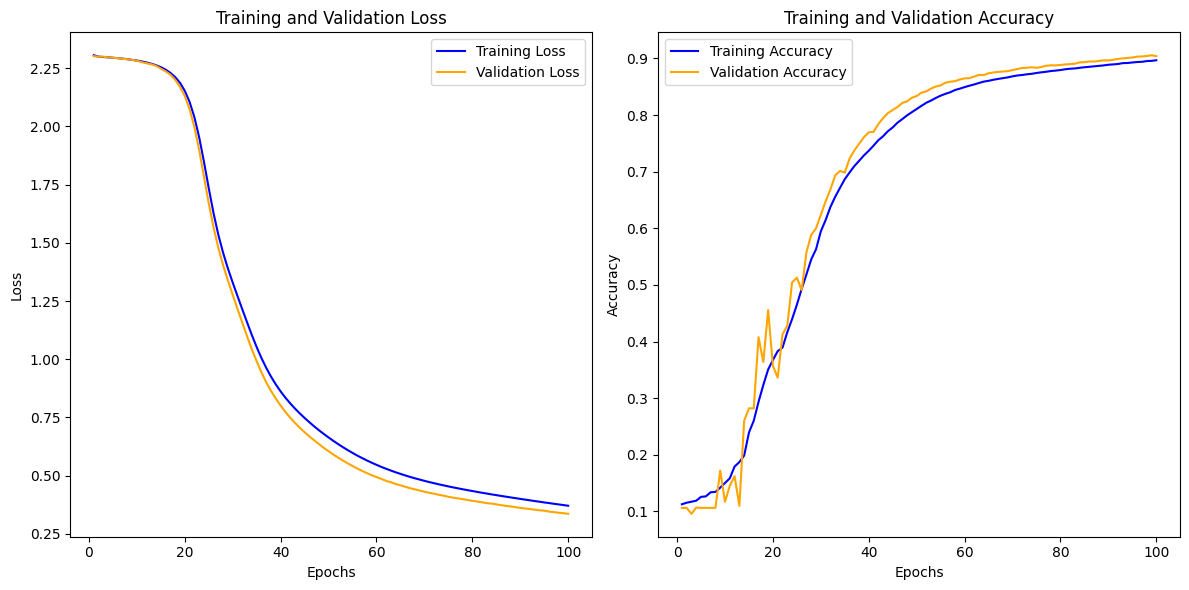

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.8991 - loss: 0.3565
Test accuracy: 0.8991


# Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

## Task 1: Data Preparation


### Loading libraries and extraction

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and ML/Week 4/devnagari digit.zip"
extract_path = "/content/devnagari"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [ ]:
base_path = "/content/devnagari/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

### Load and read image files

In [ ]:
from PIL import Image
import numpy as np

def load_data(data_dir, img_size=(28, 28)):
    X = []
    y = []

    for folder in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder)

        if not os.path.isdir(folder_path):
            continue

        # Extract label from "digit_3" → 3
        label = int(folder.split("_")[1])

        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)

            try:
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize(img_size)
                img_array = np.array(img)

                X.append(img_array)
                y.append(label)

            except:
                continue

    return np.array(X), np.array(y)

### Loss Train/Test Data and normalize

In [ ]:
X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Flatten for FCN

In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

### One-Hot Encoding

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = 10  # digits 0–9

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (17000, 784)
y_train: (17000, 10)
X_test: (3000, 784)
y_test: (3000, 10)


In [39]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Split training into train and validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

## Task 2: Build FCN Model

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Input layer and Hidden Layer 1
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))
# Hidden Layer 2
model.add(Dense(128, activation='sigmoid'))
# Hidden Layer 3
model.add(Dense(256, activation='sigmoid'))
# Output Layer
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the model

In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train

In [44]:
history = model.fit(
    X_train_final, y_train_final,
    batch_size=128,
    epochs=20,
    validation_data=(X_val, y_val)
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4232 - loss: 1.8488 - val_accuracy: 0.7271 - val_loss: 1.0742
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8011 - loss: 0.6771 - val_accuracy: 0.8565 - val_loss: 0.4798
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8755 - loss: 0.3814 - val_accuracy: 0.9038 - val_loss: 0.3301
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9240 - loss: 0.2635 - val_accuracy: 0.9300 - val_loss: 0.2508
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9460 - loss: 0.1938 - val_accuracy: 0.9465 - val_loss: 0.1977
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9568 - loss: 0.1516 - val_accuracy: 0.9497 - val_loss: 0.1710
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9641 - loss: 0.1251 - val_accuracy: 0.9585 - val_loss: 0.1484
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9712 - loss: 0.1008 - val_accura

## Visualization

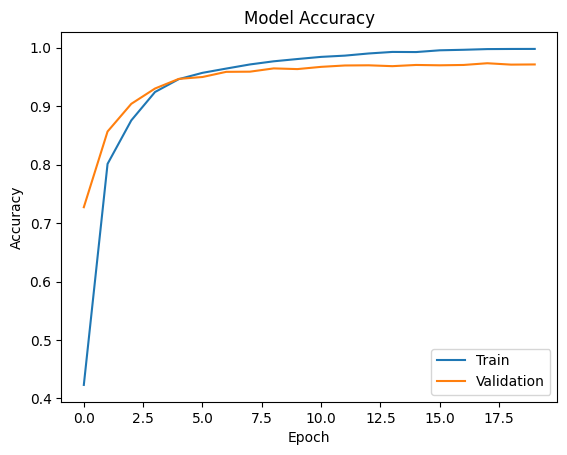

In [45]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


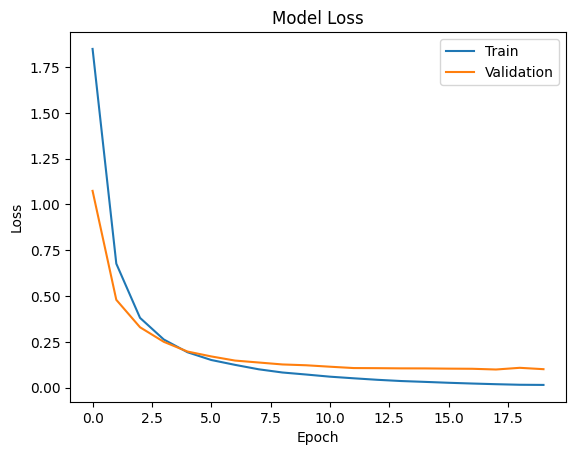

In [46]:
# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Task 5: Evaluation

In [47]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9787 - loss: 0.0757
Test Loss: 0.07574045658111572
Test Accuracy: 0.9786666631698608


# Task 6: Save and Load the Model

In [48]:
model.save("devnagari_fcn_model.keras")
print("Model saved!")

Model saved!


In [49]:
from tensorflow.keras.models import load_model

loaded_model = load_model("devnagari_fcn_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


In [52]:
loss, accuracy = loaded_model.evaluate(X_test, y_test)

print("Test Data Loss:", loss)
print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7837 - loss: 2.3189
Test Data Loss: 2.3189165592193604
Test Accuracy: 0.7836666703224182


# Task 7: Predictions

In [53]:
predictions = loaded_model.predict(X_test)

# Convert probabilities → labels
predicted_labels = np.argmax(predictions, axis=1)

# True labels (convert from one-hot)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: [3 3 2 3 3 3 3 3 3 3]
Actual: [3 3 3 3 3 3 3 3 3 3]
